<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

<h1 align=center><font size = 5>Data Analysis with Python</font></h1>


# Portfolio Project: Model Evaluation and Refinement - House Pricing Model
**Data Science Portfolio — IBM Professional Certificate Projects | Module 5: Model Evaluation and Refinement**

### 👨‍💻 Executive Summary
This notebook documents all the data analysis phases performed on a dataset of house prices from King County, Washington State, to produce and evaluate a predictive model for pricing. Following a methodic process, we addressed data wrangling, performed exploratory data analysis, model development, model evaluation, and model refinement. 

Through iterative model development, a Pipeline approach integrating Standard Scaling and Second-Order Polynomial Transformations yielded the highest performance. Utilizing a subset of 11 key independent variables, the final model achieved an $R^2$ of 0.75, successfully accounting for 75% of the price variation in the King County housing market.

---
*Original lab framework provided by IBM Skills Network. Technical implementation, 
statistical analysis, and model interpretation performed by [Roberto Castro/rcastro-ai](https://github.com/rcastro-ai)*

# House Sales in King County, USA


This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.


| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | A notation for a house                                                                                      |
| date          | Date house was sold                                                                                         |
| price         | Price is prediction target                                                                                  |
| bedrooms      | Number of bedrooms                                                                                          |
| bathrooms     | Number of bathrooms                                                                                         |
| sqft_living   | Square footage of the home                                                                                  |
| sqft_lot      | Square footage of the lot                                                                                   |
| floors        | Total floors (levels) in house                                                                              |
| waterfront    | House which has a view to a waterfront                                                                      |
| view          | Has been viewed                                                                                             |
| condition     | How good the condition is overall                                                                           |
| grade         | overall grade given to the housing unit, based on King County grading system                                |
| sqft_above    | Square footage of house apart from basement                                                                 |
| sqft_basement | Square footage of the basement                                                                              |
| yr_built      | Built Year                                                                                                  |
| yr_renovated  | Year when house was renovated                                                                               |
| zipcode       | Zip code                                                                                                    |
| lat           | Latitude coordinate                                                                                         |
| long          | Longitude coordinate                                                                                        |
| sqft_living15 | Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area |
| sqft_lot15    | LotSize area in 2015(implies-- some renovations)                                                            |


In [1]:
# If running in the browser execute this cell

# After executing the below command restart the kernel and run all cells.
#!pip3 install scikit-learn --upgrade --user

You will require the following libraries:


In [2]:
# Importing all needed libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline

# Module 1: Importing Data Sets


Load the csv:


In [3]:
# Setting values for URL and filename

filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
filename = 'house_pricing.csv'


In [4]:
# Reading dataset and storing data in dataframe df

df = pd.read_csv(filepath)

In [5]:
# Saving local copy of original file

#df.to_csv(filename)

We use the method <code>head</code> to display the first 5 columns of the dataframe.


In [6]:
# Showing the first 5 rows of the dataframe df

df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Question 1

Display the data types of each column using the function dtypes, then take a screenshot and submit it, include your code in the image.


In [7]:
# Displaying the data types of all the columns in the dataframe df

df.dtypes

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

We use the method describe to obtain a statistical summary of the dataframe.


In [8]:
# Showing the descriptive statistical summary of the dataframe df

df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


# Module 2: Data Wrangling


### Question 2

Drop the columns <code>"id"</code>  and <code>"Unnamed: 0"</code> from axis 1 using the method <code>drop()</code>, then use the method <code>describe()</code> to obtain a statistical summary of the data. Take a screenshot and submit it, make sure the <code>inplace</code> parameter is set to <code>True</code>


In [9]:
# Dropping columns "id" and "Unnamed: 0" from dataframe df

df.drop("id", axis=1, inplace=True)
df.drop("Unnamed: 0", axis=1, inplace=True)

df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


We can see we have missing values for the columns <code> bedrooms</code>  and <code> bathrooms </code>


In [10]:
# Checking for missing values for attributes 'bedrooms' and 'bathrooms'

print("Number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("Number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())


Number of NaN values for the column bedrooms : 13
Number of NaN values for the column bathrooms : 10


We can replace the missing values of the column <code>'bedrooms'</code> with the mean of the column  <code>'bedrooms' </code> using the method <code>replace()</code>. Don't forget to set the <code>inplace</code> parameter to <code>True</code>


In [11]:
# Calculating the mean for attribute 'bedrooms' and using this value to replace the null values (NaN)

mean = df['bedrooms'].mean()
#df['bedrooms'].replace(np.nan, mean, inplace=True) # This does not run in my local environment
df['bedrooms'] = df['bedrooms'].replace(np.nan, mean)

We also replace the missing values of the column <code>'bathrooms'</code> with the mean of the column  <code>'bathrooms' </code> using the method <code>replace()</code>. Don't forget to set the <code> inplace </code>  parameter top <code> True </code>


In [12]:
# Calculating the mean for attribute 'bathrooms' and using this value to replace the null values (NaN)

mean_1 = df['bathrooms'].mean()
#df['bathrooms'].replace(np.nan, mean_1, inplace=True) # This does not run in my local environment
df['bathrooms'] = df['bathrooms'].replace(np.nan, mean_1)

In [13]:
# Checking again for missing values for attributes 'bedrooms' and 'bathrooms'

print("Number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("Number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

Number of NaN values for the column bedrooms : 0
Number of NaN values for the column bathrooms : 0


# Module 3: Exploratory Data Analysis


### Question 3

Use the method <code>value_counts</code> to count the number of houses with unique floor values, use the method <code>.to_frame()</code> to convert it to a dataframe.


In [14]:
# Getting the counts of houses with the number of floors and storing the results in a new dataframe df_floors

df_floors = df["floors"].value_counts().to_frame()
df_floors

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


### Question 4

Use the function <code>boxplot</code> in the seaborn library  to  determine whether houses with a waterfront view or without a waterfront view have more price outliers.


<Axes: xlabel='waterfront', ylabel='price'>

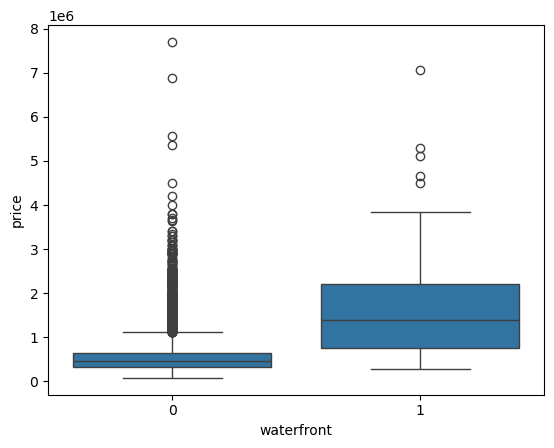

In [15]:
# Plotting the relationship between 'waterfron't and 'price' using a boxplot

sns.boxplot(x="waterfront", y="price", data=df)

**Analysis of Results**

The boxplot reveals a **positive correlation** between a waterfront view and property price, with waterfront houses commanding a substantially higher median price. However, the 'no waterfront' category contains a high density of extreme **outliers**, indicating that premium non-waterfront properties can still compete with, or exceed, the price points of waterfront homes. While 'waterfront' is a strong categorical predictor, the presence of these outliers suggests that **other features** likely exert a more dominant influence on the upper bound of market pricing.

### Question 5

Use the function <code>regplot</code>  in the seaborn library  to  determine if the feature <code>sqft_above</code> is negatively or positively correlated with price.


(0.0, 8081250.0)

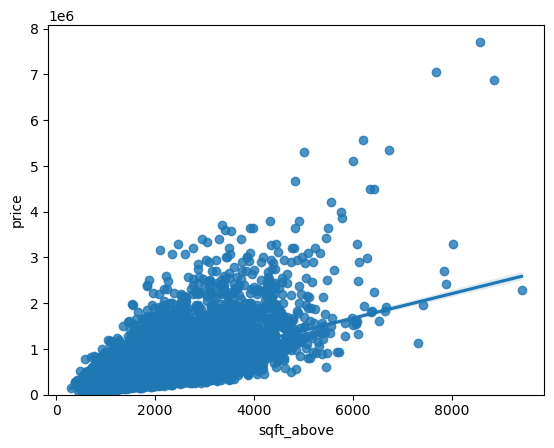

In [16]:
# Plotting the predictor variable 'sqft_above' against target variable 'price' to see if they are correlated

sns.regplot(x="sqft_above", y="price", data=df)
plt.ylim(0,)

**Analysis of Results**

The regression plot demonstrates a **strong positive linear relationship** between square footage above ground (sqft_above) and house price. The data is heavily concentrated below 4,000 square feet, with a notable increase in price variance as square footage increases. While extreme outliers exist beyond 6,000 square feet, the consistent upward trend and the tight clustering of data points around the regression line suggest that sqft_above is a statistically significant predictor of price. However, the dispersion of points at higher price levels indicates that this variable alone does not account for all price fluctuations, implying the influence of additional features.


We can use the Pandas method <code>corr()</code>  to find the feature other than price that is most correlated with price.


In [17]:
# Displaying the correlation matrix for the dataframe df to see what features have strong correlation with price

# Creating another dataframe without the column 'date'
df1 = df.drop("date", axis=1)

# Showing correlation matrix
df1.corr()['price'].sort_values()

zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308797
sqft_basement    0.323816
view             0.397293
bathrooms        0.525738
sqft_living15    0.585379
sqft_above       0.605567
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

# Module 4: Model Development


We can Fit a linear regression model using the  longitude feature <code>'long'</code> and  caculate the R^2.


In [18]:
# Creating a linear regression model for longitude and price

X = df[['long']]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
lm.score(X, Y)

0.0004676943014898516

**Analysis of Results**

The calculated $R^2$ value of **0.000467** is effectively zero, indicating that longitude alone explains virtually none of the variation in house prices. This confirms that there is no linear correlation between a property's longitudinal coordinate and its market value. While geographic location is a critical factor in real estate, this result suggests that individual coordinates do not have a direct linear impact on price, likely requiring more complex spatial analysis or combination with other variables to be useful.

### Question  6

Fit a linear regression model to predict the <code>'price'</code> using the feature <code>'sqft_living'</code> then calculate the R^2. Take a screenshot of your code and the value of the R^2.


In [19]:
# Creating a linear regression model for living square footage and price

X_1 = df[['sqft_living']]
Y_1 = df['price']
lm_1 = LinearRegression()
lm_1.fit(X_1, Y_1)
lm_1.score(X_1, Y_1)

0.4928532179037931

### Question 7

Fit a linear regression model to predict the <code>'price'</code> using the list of features:


In [20]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]     

Then calculate the R^2. Take a screenshot of your code.


In [21]:
# Creating a linear model for features "floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms",
# "sqft_living15","sqft_above","grade","sqft_living" and generating the score (R^2)

# Creating the linear regression object
lm_2 = LinearRegression()

# Creating dataframe with the predictor (independent) variables
Z_2 = df[["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]]

# Creating series containg the price information
Y_2 = df['price']

# Fitting the linear model using the dataframe containing the predictor variables and a series containing price (target variable)
lm_2.fit(Z_2, Y_2)

# Obtaining the core for the model
lm_2.score(Z_2, Y_2)


0.6576951666037496

### This will help with Question 8

Create a list of tuples, the first element in the tuple contains the name of the estimator:

<code>'scale'</code>

<code>'polynomial'</code>

<code>'model'</code>

The second element in the tuple  contains the model constructor

<code>StandardScaler()</code>

<code>PolynomialFeatures(include_bias=False)</code>

<code>LinearRegression()</code>


### Question 8

Use the list to create a pipeline object to predict the 'price', fit the object using the features in the list <code>features</code>, and calculate the R^2.


In [22]:
# Creating a pipeline to predict target variable price using the list of features from the previous block

# Creating dataframe with the predictor (independent) variables
X_3 = df[["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]]

# Creating series containg the price information
Y_3 = df['price']

# Creating list of tuples
Input = [('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]

# Creating the pipeline
pipe_3 = Pipeline(Input)

# Fitting the model - Using set of multiple features
Z_3 = X_3.astype(float)
pipe_3.fit(Z_3, Y_3)

# Generating predicted values
Ypipe_3 = pipe_3.predict(X_3)

# Calculating R-squared 
r2_3 = r2_score(Y_3, Ypipe_3)

# Printing R^2 for this model
print('R-squared is: ', r2_3)

R-squared is:  0.7513408515988733


# Module 5: Model Evaluation and Refinement


Import the necessary modules:


In [23]:
# Importing additional libraries

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
print("Done")

Done


We will split the data into training and testing sets:


In [24]:
# Splitting the data to have training and test data sets

features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    
X_4 = df[features]
Y_4 = df['price']

x_train_4, x_test_4, y_train_4, y_test_4 = train_test_split(X_4, Y_4, test_size=0.15, random_state=1)

print("Number of training samples:", x_train_4.shape[0])
print("Number of test samples:", x_test_4.shape[0])

Number of training samples: 18371
Number of test samples: 3242


### Question 9

Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and calculate the R^2 using the test data.


In [25]:
# Importing needed library

from sklearn.linear_model import Ridge

In [26]:
# Creating a Ridge regression object using training data with regularization parameter of 0.1

# Creating a Ridge regression with alpha (regularization parameter) set to 0.1
RM_4 = Ridge(alpha=0.1)

# Fitting the model
RM_4.fit(x_train_4, y_train_4)

# Obtaining the score
r_squared_4 = RM_4.score(x_test_4, y_test_4)

# Printing the R-squared for the model
print('R-squared for the model is: ', r_squared_4)


R-squared for the model is:  0.6478759163939117


### Question 10

Perform a second order polynomial transform on both the training data and testing data. Create and fit a Ridge regression object using the training data, set the regularisation parameter to 0.1, and calculate the R^2 utilising the test data provided. Take a screenshot of your code and the R^2.


In [27]:
# Creating a Ridge regression object using training data with regularization parameter of 0.1

# Splitting the data to have training and test data sets

features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    
X_5 = df[features]
Y_5 = df['price']

x_train_5, x_test_5, y_train_5, y_test_5 = train_test_split(X_5, Y_5, test_size=0.15, random_state=1)

# Creating polynomial 
pr_5 = PolynomialFeatures(degree=2)

# Transforming training and test data sets
x_train_pr_5 = pr_5.fit_transform(x_train_5) # fit and transform the training data (Learns the structure + applies it)
#x_test_pr_5 = pr_5.fit_transform(x_test_5) 
x_test_pr_5 = pr_5.transform(x_test_5) # ONLY Transform the test data (Applies the structure learned from training)

# Creating a Ridge regression with alpha (regularization parameter) set to 0.1
RM_5 = Ridge(alpha=0.1)

# Fitting the model
RM_5.fit(x_train_pr_5, y_train_5)

# Obtaining the score
r_squared_5 = RM_5.score(x_test_pr_5, y_test_5)

# Printing the R-squared for the model
print('R-squared for the model is: ', r_squared_5)


R-squared for the model is:  0.7002744297798373


<h2>About the Authors:</h2> 

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


Other contributors: <a href="https://www.linkedin.com/in/michelleccarey/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Michelle Carey</a>, <a href="https://www.linkedin.com/in/jiahui-mavis-zhou-a4537814a?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01">Mavis Zhou</a>


## Change Log

| Date (YYYY-MM-DD) | Version | Changed By      | Change Description                           |
| ----------------- | ------- | --------------- | -------------------------------------------- |
| 2022-07-29        | 2.3     | Lakshmi Holla | Added library import |
| 2020-12-01        | 2.2     | Aije Egwaikhide | Coverted Data describtion from text to table |
| 2020-10-06        | 2.1     | Lakshmi Holla   | Changed markdown instruction of Question1    |
| 2020-08-27        | 2.0     | Malika Singla   | Added lab to GitLab                          |

<hr>

## <h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>

<p>
